# 02 — Segment cells and assign transcripts

Runs Cellpose on a centre crop of the OME-TIFF image, then assigns each Xenium transcript
to a cell based on whether its spatial coordinate falls inside a segmented mask.

**Inputs**
- `data/morphology_focus_0000.ome.tif` — full morphology image
- `data/transcripts.parquet` — Xenium transcript table with `x_location`, `y_location`, `feature_name`

**Outputs**
- `data/masks_center.npy` — Cellpose segmentation mask (512 × 512)
- `data/cell_expression_aligned.csv` — cells × genes count matrix
- `outputs/center_crop.png`
- `outputs/center_crop_normalized.png`
- `outputs/overlay_center.png`
- `outputs/assignment_qc.png`

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import pyarrow.parquet as pq
from cellpose import models

## Config

In [2]:
IMAGE_PATH       = "../data/morphology_focus_0000.ome.tif"
TRANSCRIPT_PATH  = "../data/transcripts.parquet"
SHARED_GENES_PATH = "../data/shared_genes.txt"

MASK_PATH        = "../data/masks_center.npy"
CELL_EXPR_PATH   = "../data/cell_expression_aligned.csv"
OUTPUT_DIR       = "../outputs"

CROP_SIZE        = 512
CELL_DIAMETER    = 30    # expected cell diameter in pixels — adjust if segmentation looks off
GENE_COL         = "feature_name"  
X_COL            = "x_location"
Y_COL            = "y_location"

MARKER_GENES = {
    "ductal":      ["CFTR", "KRT7", "EHF", "ANPEP", "EPCAM"],
    "acinar":      ["AMY2A", "DMBT1", "HMGCS2"],
    "stellate":    ["ACTA2", "PDGFRB", "PDGFRA", "MYH11", "MYLK", "THY1"],
    "endothelial": ["PECAM1", "VWF", "EGFL7", "RAMP2", "SOX18"],
    "immune":      ["PTPRC", "CD3E", "CD68", "NKG7", "GNLY", "GZMB", "CD8A", "CD4"],
    "mast":        ["MS4A2", "FCER1A", "CPA3"],
    "cycling":     ["MKI67", "TOP2A", "CCNB2", "CENPF", "UBE2C"],
}

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1 · Load image and take centre crop

In [3]:
with tiff.TiffFile(IMAGE_PATH) as tif:
    img = tif.pages[0].asarray()

print("Original shape:", img.shape)

if img.ndim == 3:
    img = img[..., 0]

h, w = img.shape
start_y = h // 2 - CROP_SIZE // 2
start_x = w // 2 - CROP_SIZE // 2
img_crop = img[start_y:start_y + CROP_SIZE, start_x:start_x + CROP_SIZE]

print(f"Crop shape: {img_crop.shape}  |  pixel range: [{img_crop.min()}, {img_crop.max()}]")
print(f"Crop offsets — start_x: {start_x}, start_y: {start_y}")

plt.figure(figsize=(6, 6))
plt.imshow(img_crop, cmap="gray")
plt.title("Centre crop")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "center_crop.png"), bbox_inches="tight", dpi=200)
plt.close()

Original shape: (13770, 34155)
Crop shape: (512, 512)  |  pixel range: [0, 4530]
Crop offsets — start_x: 16821, start_y: 6629


## 2 · Normalise crop for Cellpose

In [4]:
img_crop = img_crop.astype(np.float32)
pmin, pmax = img_crop.min(), img_crop.max()

if pmax <= pmin:
    raise ValueError(
        "Crop is blank (min == max). "
        "Try adjusting CROP_SIZE or start_x/start_y to a region with tissue."
    )

img_crop_norm = (img_crop - pmin) / (pmax - pmin)

plt.figure(figsize=(6, 6))
plt.imshow(img_crop_norm, cmap="gray")
plt.title("Normalised centre crop")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "center_crop_normalized.png"), bbox_inches="tight", dpi=200)
plt.close()

In [5]:
# cells = pd.read_csv(CELL_EXPR_PATH, index_col=0)

# # drop Xenium control probes — not real genes
# control_cols = [c for c in cells.columns if "NegControl" in c or "UnassignedCodeword" in c]
# if control_cols:
#     print("Dropping control columns:", control_cols)
#     cells = cells.drop(columns=control_cols)

## 3 · Run Cellpose

In [6]:
model = models.CellposeModel(gpu=True)

t0 = time.time()
masks, flows, styles = model.eval(
    img_crop_norm,
    diameter=CELL_DIAMETER,
    batch_size=8
)
print(f"Cellpose finished in {time.time() - t0:.1f}s  |  cells found: {int(masks.max())}")

np.save(MASK_PATH, masks)
print(f"Saved mask → {MASK_PATH}")

plt.figure(figsize=(6, 6))
plt.imshow(img_crop_norm, cmap="gray")
plt.contour(masks, levels=np.unique(masks)[1:], linewidths=0.3)
plt.title("Segmentation overlay")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "overlay_center.png"), bbox_inches="tight", dpi=200)
plt.close()

/Users/mehdi/Desktop/Computational Genomics Project/venv/lib/python3.13/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Cellpose finished in 6.5s  |  cells found: 83
Saved mask → ../data/masks_center.npy


## 4 · Assign transcripts to cells

Transcripts are stored in full-image pixel coordinates. We subtract the crop offset so
coordinates line up with the 512×512 mask, then look up each transcript's cell ID.

In [7]:
transcripts = pq.read_table(TRANSCRIPT_PATH).to_pandas()
print("Transcript columns:", transcripts.columns.tolist())
print(f"Total transcripts: {len(transcripts):,}")

# sanity-check column names — update GENE_COL / X_COL / Y_COL in Config if needed
for col in [GENE_COL, X_COL, Y_COL]:
    assert col in transcripts.columns, f"Column '{col}' not found. Available: {transcripts.columns.tolist()}"

Transcript columns: ['transcript_id', 'cell_id', 'overlaps_nucleus', 'feature_name', 'x_location', 'y_location', 'z_location', 'qv', 'fov_name', 'nucleus_distance', 'codeword_index']
Total transcripts: 8,073,840


In [8]:
# debug why none get assigned
import pyarrow.parquet as pq
transcripts = pq.read_table(TRANSCRIPT_PATH).to_pandas()
print(transcripts[[X_COL, Y_COL]].describe())
print(f"\nCrop pixel range: x=[{start_x}, {start_x+CROP_SIZE}], y=[{start_y}, {start_y+CROP_SIZE}]")

         x_location    y_location
count  8.073840e+06  8.073840e+06
mean   4.286064e+03  1.393760e+03
std    1.960895e+03  7.902470e+02
min    3.095915e+00  7.418911e+00
25%    2.619865e+03  7.100435e+02
50%    4.648506e+03  1.353745e+03
75%    6.025521e+03  2.030330e+03
max    7.251915e+03  2.920684e+03

Crop pixel range: x=[16821, 17333], y=[6629, 7141]


In [9]:
MICRONS_PER_PIXEL = 0.2125

# convert crop offsets from pixels to microns
start_x_um = start_x * MICRONS_PER_PIXEL
start_y_um = start_y * MICRONS_PER_PIXEL
end_x_um   = (start_x + CROP_SIZE) * MICRONS_PER_PIXEL
end_y_um   = (start_y + CROP_SIZE) * MICRONS_PER_PIXEL

print(f"Crop in microns: x=[{start_x_um:.1f}, {end_x_um:.1f}], y=[{start_y_um:.1f}, {end_y_um:.1f}]")
print(f"Transcript x range: [{transcripts[X_COL].min():.1f}, {transcripts[X_COL].max():.1f}]")

# filter transcripts to crop region (still in microns)
in_crop = (
    (transcripts[X_COL] >= start_x_um) & (transcripts[X_COL] < end_x_um) &
    (transcripts[Y_COL] >= start_y_um) & (transcripts[Y_COL] < end_y_um)
)
tx = transcripts[in_crop].copy()
print(f"Transcripts in crop: {len(tx):,} / {len(transcripts):,}")

# convert to local pixel coordinates for mask lookup
tx["x_local"] = ((transcripts[X_COL] - start_x_um) / MICRONS_PER_PIXEL).astype(int).clip(0, CROP_SIZE-1)
tx["y_local"] = ((transcripts[Y_COL] - start_y_um) / MICRONS_PER_PIXEL).astype(int).clip(0, CROP_SIZE-1)

tx["cell_id"] = masks[tx["y_local"], tx["x_local"]]

assigned   = tx[tx["cell_id"] > 0]
unassigned = tx[tx["cell_id"] == 0]
print(f"Assigned: {len(assigned):,}  |  Unassigned: {len(unassigned):,}")

Crop in microns: x=[3574.5, 3683.3], y=[1408.7, 1517.5]
Transcript x range: [3.1, 7251.9]
Transcripts in crop: 6,562 / 8,073,840
Assigned: 3,099  |  Unassigned: 3,463


## 5 · Build cell × gene expression matrix

In [10]:
# load shared genes so the expression matrix uses the same gene set as the prototypes
with open(SHARED_GENES_PATH) as f:
    shared_genes = [line.strip() for line in f if line.strip()]

# count transcripts per cell per gene, then reindex to shared genes
cell_expr = (
    assigned.groupby(["cell_id", GENE_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=shared_genes, fill_value=0)
)

print("Cell expression matrix:", cell_expr.shape, "(cells × genes)")
cell_expr.to_csv(CELL_EXPR_PATH)
print(f"Saved → {CELL_EXPR_PATH}")

Cell expression matrix: (83, 126) (cells × genes)
Saved → ../data/cell_expression_aligned.csv


## 6 · QC plot

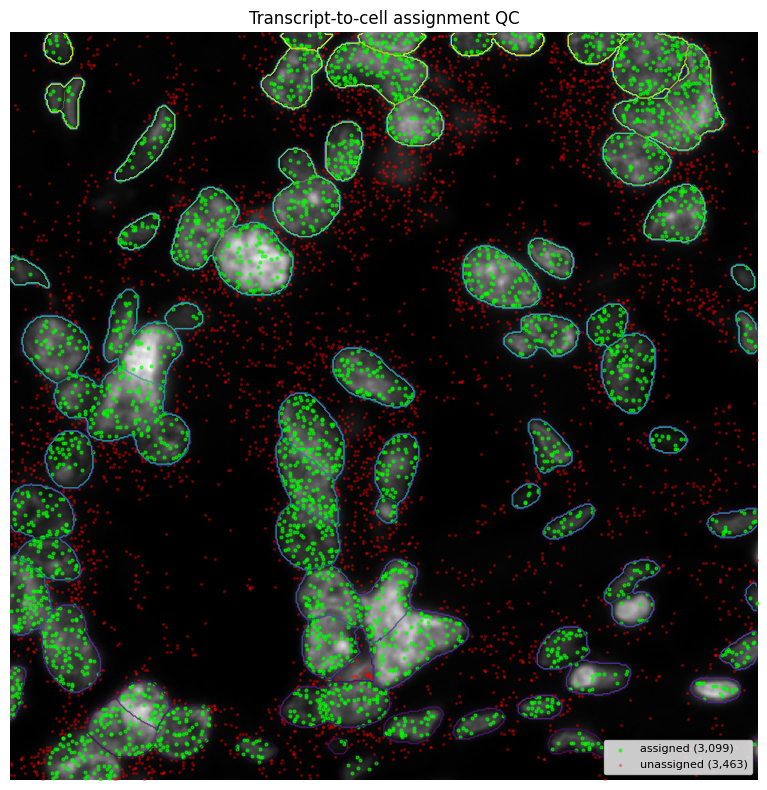

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_crop_norm, cmap="gray")

levels = np.unique(masks)
levels = levels[levels > 0]
if len(levels):
    ax.contour(masks, levels=levels, linewidths=0.2)

if len(assigned):
    ax.scatter(assigned["x_local"], assigned["y_local"],
               s=4, alpha=0.6, color="lime", label=f"assigned ({len(assigned):,})")
if len(unassigned):
    ax.scatter(unassigned["x_local"], unassigned["y_local"],
               s=2, alpha=0.3, color="red", label=f"unassigned ({len(unassigned):,})")

ax.invert_yaxis()
ax.legend(fontsize=8)
ax.set_title("Transcript-to-cell assignment QC")
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "assignment_qc.png"), dpi=300, bbox_inches="tight")
plt.show()